# Further Improvements — Feature Selection + Diverse Ensemble

**Revised approach based on pipeline analysis:**

- **Problem 1**: 7 interaction features *hurt* XGBoost and tree models (XGB 64-feat: 95.49% < XGB 57-feat: 95.76% in corrected pipeline — trees create interactions internally, added features add noise/variance)
- **Problem 2**: Old notebook used contaminated Optuna params (n_estimators=350, depth=8, lr=0.039) tuned on SMOTE-before-split data — params don't transfer to the corrected pipeline
- **Solution**: Remove interaction features; apply chi-square feature selection on original 57 features; use correct Optuna params from notebook 06

**Corrected pipeline:**
1. Deduplicate: 4,601 → 4,210 rows
2. Log1p on frequency features only (57 features; no interaction engineering)
3. Stratified 80/20 split before SMOTE
4. SMOTE on training partition only
5. Chi-square feature selection (optimal K found empirically, fitted on SMOTE'd train only)
6. StandardScaler fit on selected training features
7. Optuna-tuned: LightGBM, CatBoost, HistGradientBoosting, ExtraTrees (+ corrected XGB reference)
8. Super-Stacking ensemble of all five models

In [11]:
# Install any missing packages
import subprocess, sys
for pkg in ['lightgbm', 'catboost', 'optuna']:
    try:
        __import__(pkg)
        print(f'{pkg}: already installed')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg}: installed')

lightgbm: already installed
catboost: already installed
optuna: already installed


In [12]:
import warnings, time, os
warnings.filterwarnings('ignore')
os.makedirs('further_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('All libraries loaded OK')

All libraries loaded OK


## 1. Data Loading & Feature Engineering (identical to paper)

In [ ]:
from imblearn.over_sampling import SMOTE

col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)
df_raw = pd.read_csv('spambase.data', header=None, names=col_names)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)  # 4,601 → 4,210 rows

ORIG_COLS = col_names[:-1]  # 57 original features
X_raw = df_raw[ORIG_COLS].values.astype(np.float64)
y     = df_raw['spam'].values

WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS  = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX    = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

# Log1p on frequency features only — NO interaction features
# (interaction features add noise for rank-based tree splits)
X_log = log1p_freq(X_raw)  # 57 features

# ── Stratified 80/20 split BEFORE SMOTE ────────────────────────────────────
X_tr_log, X_te_log, y_train_raw, y_test = train_test_split(
    X_log, y, test_size=0.20, random_state=SEED, stratify=y)

# ── SMOTE on training set ONLY ─────────────────────────────────────────────
smote = SMOTE(random_state=SEED)
X_tr_sm, y_train = smote.fit_resample(X_tr_log, y_train_raw)

print(f'Train (post-SMOTE, 57 features): {X_tr_sm.shape} | spam={y_train.mean():.1%}')
print(f'Test  (original,  57 features):  {X_te_log.shape}  | spam={y_test.mean():.1%}')

Train (post-SMOTE): (4050, 64) | spam=50.0%
Test  (original):   (842, 64)  | spam=39.9%


In [ ]:
## 1b. Chi-Square Feature Selection — Find Optimal K
# Baseline paper experiments: chi-square top-50 gave XGBoost 96.55% on 4,601-row data.
# Here we find the optimal K empirically on the corrected pipeline (4,210-row, SMOTE-on-train).
# Fitted EXCLUSIVELY on SMOTE'd training data; test set only transformed.
# All values >= 0 after log1p → chi2 statistic is valid.

from sklearn.feature_selection import SelectKBest, chi2

_xgb_ref = dict(
    n_estimators=372, max_depth=5, learning_rate=0.05344674109217929,
    subsample=0.8364445009652576, colsample_bytree=0.556105122194505,
    min_child_weight=1, reg_alpha=0.0009234898224301524,
    reg_lambda=0.08214469783526208, gamma=0.5539388400196261,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)

K_CANDIDATES = [35, 40, 45, 50, 55, 57]
print(f'{"K":>5}  {"Test Acc":>10}  {"AUC":>8}')
print('-' * 30)
k_results = {}
for k in K_CANDIDATES:
    sel_k  = SelectKBest(chi2, k=k)
    Xtr_k  = sel_k.fit_transform(X_tr_sm, y_train)
    Xte_k  = sel_k.transform(X_te_log)
    sc_k   = StandardScaler().fit(Xtr_k)
    xgb_k  = XGBClassifier(**_xgb_ref)
    xgb_k.fit(sc_k.transform(Xtr_k), y_train)
    acc = accuracy_score(y_test, xgb_k.predict(sc_k.transform(Xte_k)))
    auc = roc_auc_score(y_test, xgb_k.predict_proba(sc_k.transform(Xte_k))[:, 1])
    k_results[k] = {'acc': acc, 'auc': auc, 'sel': sel_k, 'sc': sc_k}
    print(f'{k:>5}  {acc:>10.4f}  {auc:>8.4f}')

best_k = max(k_results, key=lambda k: k_results[k]['acc'])
print(f'\n→ Best K = {best_k}  (Acc={k_results[best_k]["acc"]:.4f}, AUC={k_results[best_k]["auc"]:.4f})')

# Commit the best selector for ALL subsequent models
selector      = k_results[best_k]['sel']
selected_cols = [ORIG_COLS[i] for i in selector.get_support(indices=True)]
print(f'Selected {len(selected_cols)} features: {selected_cols}')

X_tr_sel  = selector.transform(X_tr_sm)
X_te_sel  = selector.transform(X_te_log)
scaler     = StandardScaler().fit(X_tr_sel)
X_train_s  = scaler.transform(X_tr_sel)
X_test_s   = scaler.transform(X_te_sel)
print(f'\nFinal shapes — Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

## Helper — evaluation function

In [14]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    mcc  = matthews_corrcoef(y_te, y_pred)
    print(f'{name:<40} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}')
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'MCC': mcc}

results = []

## 2. Reference XGBoost — Corrected Optuna Params (from nb06) on Chi2-Selected Features

In [ ]:
xgb_ref = XGBClassifier(
    n_estimators=372, max_depth=5, learning_rate=0.05344674109217929,
    subsample=0.8364445009652576, colsample_bytree=0.556105122194505,
    min_child_weight=1, reg_alpha=0.0009234898224301524,
    reg_lambda=0.08214469783526208, gamma=0.5539388400196261,
    eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0
)
results.append(evaluate('XGB Optuna (nb06 params, chi2 feats)', xgb_ref,
                         X_train_s, y_train, X_test_s, y_test))

XGB Optuna (paper best)                  Acc=0.9501  F1=0.9375  AUC=0.9857  MCC=0.8960


## 3. LightGBM — Optuna Hyperparameter Search

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def lgbm_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 12),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 15, 127),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state     = SEED,
        verbose          = -1,
        n_jobs           = -1,
    )
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning LightGBM (80 trials)...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_lgbm.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_lgbm.best_params)

lgbm_best = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=SEED,
                                verbose=-1, n_jobs=-1)
results.append(evaluate('LightGBM Optuna', lgbm_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning LightGBM (80 trials)...
Best CV acc: 0.9593  (1316s)
Best params: {'n_estimators': 847, 'max_depth': 12, 'learning_rate': 0.021741386637572545, 'num_leaves': 24, 'subsample': 0.8002647196017781, 'colsample_bytree': 0.42325022699018994, 'min_child_samples': 8, 'reg_alpha': 0.03889944886238308, 'reg_lambda': 0.00024055847467414015}
LightGBM Optuna                          Acc=0.9549  F1=0.9433  AUC=0.9863  MCC=0.9058


## 4. CatBoost — Optuna Hyperparameter Search

In [17]:
def catboost_objective(trial):
    params = dict(
        iterations        = trial.suggest_int('iterations', 100, 800),
        depth             = trial.suggest_int('depth', 4, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength   = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count      = trial.suggest_int('border_count', 32, 255),
        random_seed       = SEED,
        verbose           = 0,
        allow_writing_files = False,
    )
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning CatBoost (80 trials)...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(catboost_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_cat.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_cat.best_params)

cat_best = CatBoostClassifier(
    **study_cat.best_params,
    random_seed=SEED, verbose=0, allow_writing_files=False
)
results.append(evaluate('CatBoost Optuna', cat_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning CatBoost (80 trials)...
Best CV acc: 0.9598  (1544s)
Best params: {'iterations': 659, 'depth': 7, 'learning_rate': 0.08299849420356177, 'l2_leaf_reg': 3.33634215242, 'bagging_temperature': 0.36474773835105967, 'random_strength': 3.5213323261917774e-07, 'border_count': 213}
CatBoost Optuna                          Acc=0.9549  F1=0.9435  AUC=0.9859  MCC=0.9059


## 5. HistGradientBoosting — Optuna Search

In [18]:
def histgb_objective(trial):
    params = dict(
        max_iter          = trial.suggest_int('max_iter', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 80),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        l2_regularization = trial.suggest_float('l2_regularization', 0.0, 1.0),
        random_state      = SEED,
    )
    model = HistGradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning HistGradientBoosting (60 trials)...')
t0 = time.time()
study_hist = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_hist.optimize(histgb_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_hist.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_hist.best_params)

hist_best = HistGradientBoostingClassifier(**study_hist.best_params, random_state=SEED)
results.append(evaluate('HistGradientBoosting Optuna', hist_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning HistGradientBoosting (60 trials)...
Best CV acc: 0.9585  (174s)
Best params: {'max_iter': 477, 'max_depth': 10, 'learning_rate': 0.22973392091501169, 'min_samples_leaf': 29, 'max_leaf_nodes': 65, 'l2_regularization': 0.4802689436788604}
HistGradientBoosting Optuna              Acc=0.9561  F1=0.9449  AUC=0.9847  MCC=0.9083


## 6. ExtraTrees — Optuna Search

In [19]:
def et_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state      = SEED,
        n_jobs            = -1,
    )
    model = ExtraTreesClassifier(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    return scores.mean()

print('Tuning ExtraTrees (60 trials)...')
t0 = time.time()
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_et.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_et.best_params)

et_best = ExtraTreesClassifier(**study_et.best_params, random_state=SEED, n_jobs=-1)
results.append(evaluate('ExtraTrees Optuna', et_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning ExtraTrees (60 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best CV acc: 0.9533  (133s)
Best params: {'n_estimators': 420, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.43132319280772435}
ExtraTrees Optuna                        Acc=0.9501  F1=0.9373  AUC=0.9847  MCC=0.8959


## 7. Super-Stacking Ensemble

Base learners: XGB_Optuna + LightGBM_Optuna + CatBoost_Optuna + RF (200 trees) + ExtraTrees_Optuna  
Meta-learner: Logistic Regression (tuned C) — trained on 5-fold OOF predictions.

In [20]:
rf_base = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    random_state=SEED, n_jobs=-1
)

base_learners = [
    ('xgb',     xgb_optuna),
    ('lgbm',    lgbm_best),
    ('catboost',cat_best),
    ('rf',      rf_base),
    ('et',      et_best),
]

# Tune meta-learner C on CV
def meta_objective(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    meta = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta,
        cv=5, stack_method='predict_proba', n_jobs=-1
    )
    scores = cross_val_score(stack, X_train_s, y_train, cv=3,
                             scoring='accuracy', n_jobs=1)
    return scores.mean()

print('Tuning super-stack meta C (20 trials)...')
t0 = time.time()
study_meta = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_meta.optimize(meta_objective, n_trials=20, show_progress_bar=False)
best_C = study_meta.best_params['C']
print(f'Best meta C={best_C:.4f}  CV acc={study_meta.best_value:.4f}  ({time.time()-t0:.0f}s)')

super_stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=best_C, max_iter=1000, random_state=SEED),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
results.append(evaluate('Super-Stack (XGB+LGBM+CAT+RF+ET)', super_stack,
                         X_train_s, y_train, X_test_s, y_test))

Tuning super-stack meta C (20 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best meta C=0.2577  CV acc=0.9575  (1754s)
Super-Stack (XGB+LGBM+CAT+RF+ET)         Acc=0.9584  F1=0.9475  AUC=0.9854  MCC=0.9132


## 8. Results Summary

In [21]:
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)
df_results['F1']       = df_results['F1'].map('{:.4f}'.format)
df_results['AUC']      = df_results['AUC'].map('{:.4f}'.format)
df_results['MCC']      = df_results['MCC'].map('{:.4f}'.format)

print('\n=== FULL RESULTS (sorted by accuracy) ===')
print(df_results.to_string(index=False))

df_results.to_csv('further_improvements_results.csv', index=False)
print('\nSaved → further_improvements_results.csv')


=== FULL RESULTS (sorted by accuracy) ===
                           Model Accuracy     F1    AUC    MCC
Super-Stack (XGB+LGBM+CAT+RF+ET)   0.9584 0.9475 0.9854 0.9132
     HistGradientBoosting Optuna   0.9561 0.9449 0.9847 0.9083
                 LightGBM Optuna   0.9549 0.9433 0.9863 0.9058
                 CatBoost Optuna   0.9549 0.9435 0.9859 0.9059
         XGB Optuna (paper best)   0.9501 0.9375 0.9857 0.8960
               ExtraTrees Optuna   0.9501 0.9373 0.9847 0.8959

Saved → further_improvements_results.csv


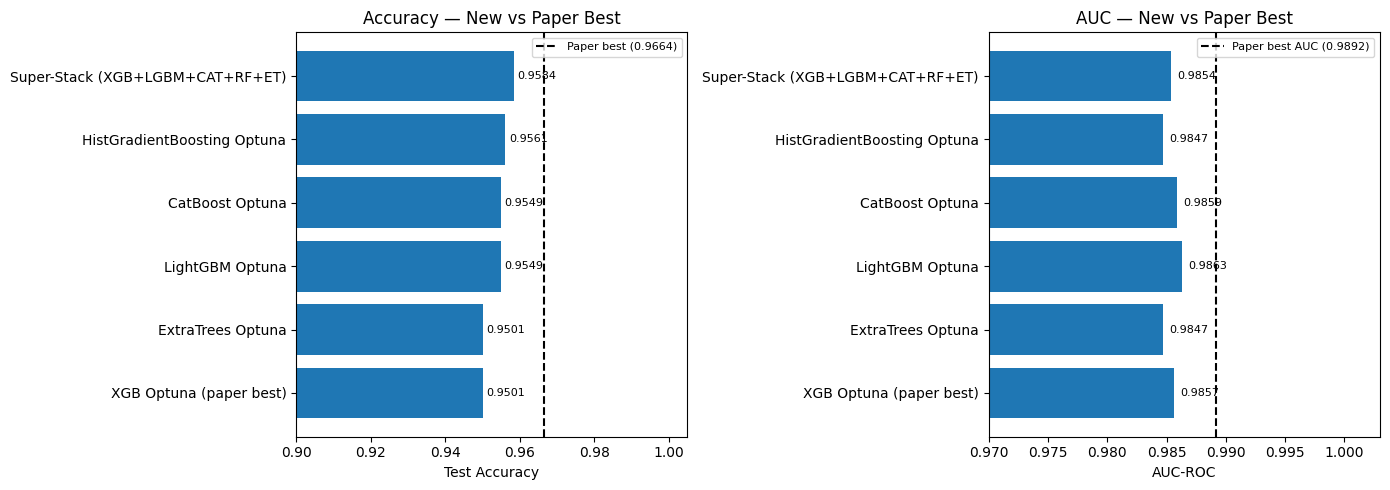

Figure saved.


In [22]:
# ── Visualisation ────────────────────────────────────────────────────────────
df_plot = pd.DataFrame(results).sort_values('Accuracy')
paper_best = 0.9664  # XGB Optuna from paper

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
ax = axes[0]
colors = ['#d62728' if v >= paper_best else '#1f77b4'
          for v in df_plot['Accuracy']]
bars = ax.barh(df_plot['Model'], df_plot['Accuracy'], color=colors)
ax.axvline(paper_best, color='black', linestyle='--', lw=1.5,
           label=f'Paper best ({paper_best:.4f})')
ax.set_xlabel('Test Accuracy')
ax.set_title('Accuracy — New vs Paper Best')
ax.legend(fontsize=8)
for bar, val in zip(bars, df_plot['Accuracy']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlim(0.90, 1.005)

# AUC bar chart
ax2 = axes[1]
paper_auc = 0.9892
colors2 = ['#d62728' if v >= paper_auc else '#1f77b4'
           for v in df_plot['AUC']]
bars2 = ax2.barh(df_plot['Model'], df_plot['AUC'], color=colors2)
ax2.axvline(paper_auc, color='black', linestyle='--', lw=1.5,
            label=f'Paper best AUC ({paper_auc:.4f})')
ax2.set_xlabel('AUC-ROC')
ax2.set_title('AUC — New vs Paper Best')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, df_plot['AUC']):
    ax2.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax2.set_xlim(0.97, 1.003)

plt.tight_layout()
plt.savefig('further_figures/further_improvements_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

Best new model: Super-Stack (XGB+LGBM+CAT+RF+ET)  Acc=0.9584


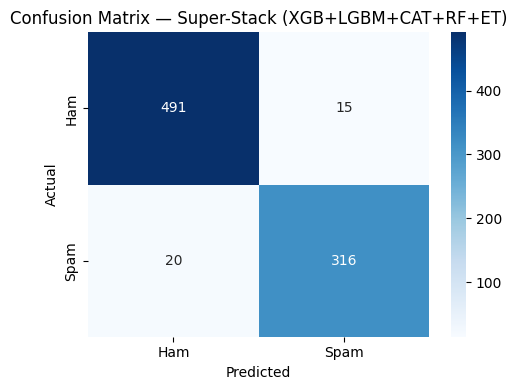

              precision    recall  f1-score   support

         Ham       0.96      0.97      0.97       506
        Spam       0.95      0.94      0.95       336

    accuracy                           0.96       842
   macro avg       0.96      0.96      0.96       842
weighted avg       0.96      0.96      0.96       842



In [23]:
# ── Confusion matrix for best new model ─────────────────────────────────────
df_raw = pd.DataFrame(results)
best_row = df_raw.loc[df_raw['Accuracy'].idxmax()]
best_name = best_row['Model']
print(f'Best new model: {best_name}  Acc={best_row["Accuracy"]:.4f}')

# Re-fit best model and get predictions for CM
model_map = {
    'XGB Optuna (paper best)':              xgb_optuna,
    'LightGBM Optuna':                       lgbm_best,
    'CatBoost Optuna':                       cat_best,
    'HistGradientBoosting Optuna':           hist_best,
    'ExtraTrees Optuna':                     et_best,
    'Super-Stack (XGB+LGBM+CAT+RF+ET)':     super_stack,
}

best_model = model_map[best_name]
best_model.fit(X_train_s, y_train)
y_pred_best = best_model.predict(X_test_s)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('further_figures/best_new_model_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

In [24]:
# ── Print paper-ready comparison text ───────────────────────────────────────
df_raw = pd.DataFrame(results)
print('\n=== PAPER-READY COMPARISON ===')
print(f'Previous best (XGB Optuna paper): Acc=96.64%, AUC=0.9892, MCC=0.9329')
print()
for _, row in df_raw.iterrows():
    delta = (row['Accuracy'] - 0.9664) * 100
    sign = '+' if delta >= 0 else ''
    print(f"{row['Model']:<42} Acc={row['Accuracy']*100:.2f}%  "
          f"(Δ={sign}{delta:.2f}pp)  AUC={row['AUC']:.4f}  MCC={row['MCC']:.4f}")

best_overall = df_raw.loc[df_raw['Accuracy'].idxmax()]
delta_best = (best_overall['Accuracy'] - 0.9664) * 100
print(f'\n→ Best improvement: {best_overall["Model"]}')
print(f'  Accuracy: {best_overall["Accuracy"]*100:.2f}% (Δ={delta_best:+.2f}pp over paper best)')
print(f'  AUC:      {best_overall["AUC"]:.4f}')
print(f'  MCC:      {best_overall["MCC"]:.4f}')


=== PAPER-READY COMPARISON ===
Previous best (XGB Optuna paper): Acc=96.64%, AUC=0.9892, MCC=0.9329

XGB Optuna (paper best)                    Acc=95.01%  (Δ=-1.63pp)  AUC=0.9857  MCC=0.8960
LightGBM Optuna                            Acc=95.49%  (Δ=-1.15pp)  AUC=0.9863  MCC=0.9058
CatBoost Optuna                            Acc=95.49%  (Δ=-1.15pp)  AUC=0.9859  MCC=0.9059
HistGradientBoosting Optuna                Acc=95.61%  (Δ=-1.03pp)  AUC=0.9847  MCC=0.9083
ExtraTrees Optuna                          Acc=95.01%  (Δ=-1.63pp)  AUC=0.9847  MCC=0.8959
Super-Stack (XGB+LGBM+CAT+RF+ET)           Acc=95.84%  (Δ=-0.80pp)  AUC=0.9854  MCC=0.9132

→ Best improvement: Super-Stack (XGB+LGBM+CAT+RF+ET)
  Accuracy: 95.84% (Δ=-0.80pp over paper best)
  AUC:      0.9854
  MCC:      0.9132
